In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/raw/creditcard.csv')
df['trans_datetime'] = pd.to_datetime(df['trans_date_trans_time'])

print(f"Data loaded: {df.shape}")

Data loaded: (339607, 16)


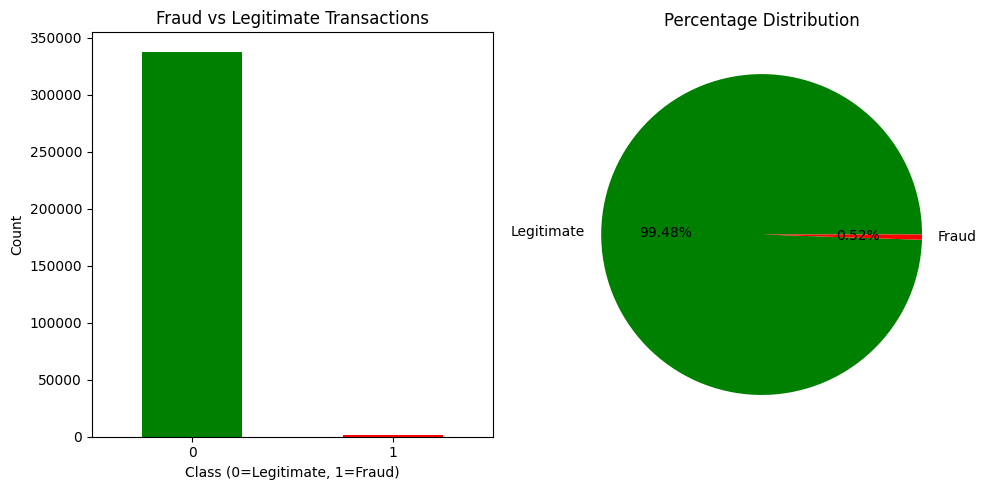

In [13]:
# % of legitimate vs fraud transactions
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
df['is_fraud'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('Class (0=Legitimate, 1=Fraud)')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
plt.pie([337825, 1782], labels=['Legitimate', 'Fraud'], autopct='%1.2f%%', colors=['green', 'red'])
plt.title('Percentage Distribution')

plt.tight_layout()
plt.show()

In [14]:
# Amount of charge mean for fraudulant and legit transactions
print("Amount Statistics:")
print(df['amt'].describe())

print("\n" + "="*50)
print("Amount by Class:")
print(df.groupby('is_fraud')['amt'].describe())

Amount Statistics:
count    339607.000000
mean         70.577984
std         161.675242
min           1.000000
25%           9.600000
50%          46.460000
75%          83.350000
max       28948.900000
Name: amt, dtype: float64

Amount by Class:
             count        mean         std   min       25%      50%      75%  \
is_fraud                                                                       
0         337825.0   68.217523  156.251647  1.00    9.5700   46.250   82.760   
1           1782.0  518.065460  389.627409  1.78  214.6775  356.435  884.725   

               max  
is_fraud            
0         28948.90  
1          1371.81  


In [15]:
# Amount of fraudulant by category of pruchases
fraud_by_cat = df.groupby('category')['is_fraud'].agg(['sum', 'count', 'mean'])
fraud_by_cat.columns = ['Fraud_Count', 'Total', 'Fraud_Rate']
fraud_by_cat['Fraud_Rate'] = fraud_by_cat['Fraud_Rate'] * 100
fraud_by_cat = fraud_by_cat.sort_values('Fraud_Rate', ascending=False)

print("Top 10 Categories by Fraud Rate:")
print(fraud_by_cat.head(10))

Top 10 Categories by Fraud Rate:
               Fraud_Count  Total  Fraud_Rate
category                                     
shopping_net           381  26379    1.444331
grocery_pos            433  32732    1.322864
misc_net               217  16898    1.284176
shopping_pos           187  30329    0.616572
gas_transport          153  35089    0.436034
travel                  33  10322    0.319705
misc_pos                62  20024    0.309628
grocery_net             27  11355    0.237781
entertainment           55  24222    0.227066
personal_care           55  24406    0.225354


Fraud rate by hour:
hour
0     1.521877
1     1.494529
2     1.270533
3     1.273715
4     0.064197
5     0.090719
6     0.062808
7     0.081125
8     0.107885
9     0.100027
10    0.089904
11    0.054466
12    0.099021
13    0.081752
14    0.088868
15    0.128138
16    0.131692
17    0.117571
18    0.105752
19    0.063668
20    0.132963
21    0.098454
22    2.588774
23    2.620461
Name: is_fraud, dtype: float64


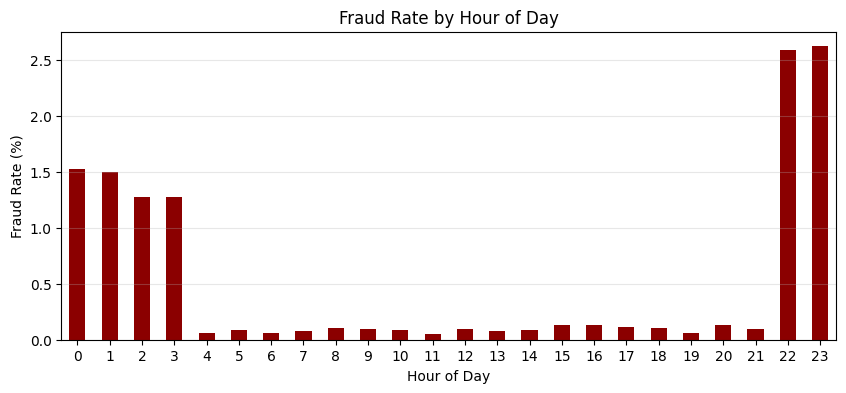

In [16]:
# Fraud rate by hour 
df['trans_datetime'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_datetime'].dt.hour

fraud_by_hour = df.groupby('hour')['is_fraud'].mean() * 100

print("Fraud rate by hour:")
print(fraud_by_hour)

plt.figure(figsize=(10, 4))
fraud_by_hour.plot(kind='bar', color='darkred')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Hour of Day')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

Top 10 States by Fraud Rate:
       Fraud_Count  Total  Fraud_Rate
state                                
AK              50   2963    1.687479
OR             197  26408    0.745986
NE             216  34425    0.627451
CO             115  19766    0.581807
NM             121  23427    0.516498
CA             402  80495    0.499410
MO             262  54904    0.477197
WA             126  27040    0.465976
HI              16   3649    0.438476
WY             119  27776    0.428427


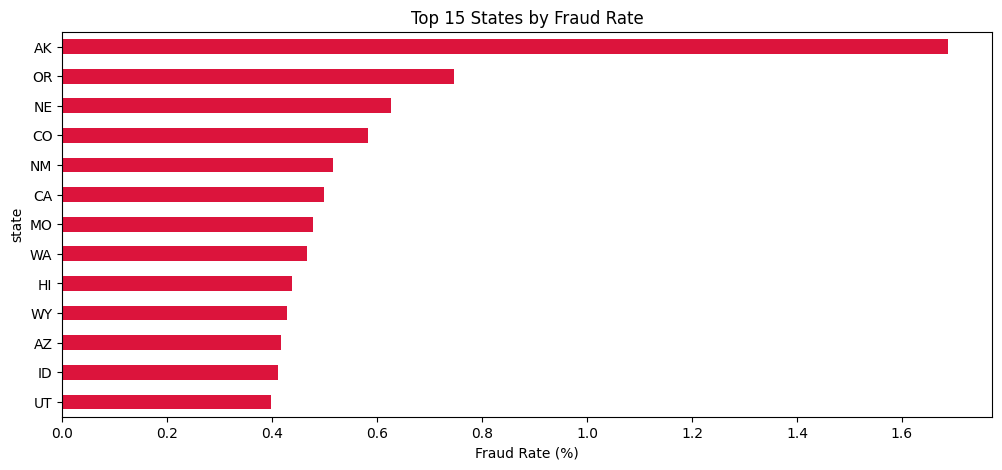

In [17]:
# Fraud rates for particular states
state_fraud = df.groupby('state')['is_fraud'].agg(['sum', 'count', 'mean'])
state_fraud.columns = ['Fraud_Count', 'Total', 'Fraud_Rate']
state_fraud['Fraud_Rate'] = state_fraud['Fraud_Rate'] * 100
state_fraud = state_fraud.sort_values('Fraud_Rate', ascending=False)

print("Top 10 States by Fraud Rate:")
print(state_fraud.head(10))

plt.figure(figsize=(12, 5))
state_fraud.head(15)['Fraud_Rate'].plot(kind='barh', color='crimson')
plt.xlabel('Fraud Rate (%)')
plt.title('Top 15 States by Fraud Rate')
plt.gca().invert_yaxis()
plt.show()

Fraud Rate by City Size:
              Fraud_Count   Total  Fraud_Rate
pop_category                                 
Very Small            708  136897    0.517177
Small                 520   87868    0.591797
Medium                218   59898    0.363952
Large                 292   43246    0.675207
Very Large             44   11698    0.376133


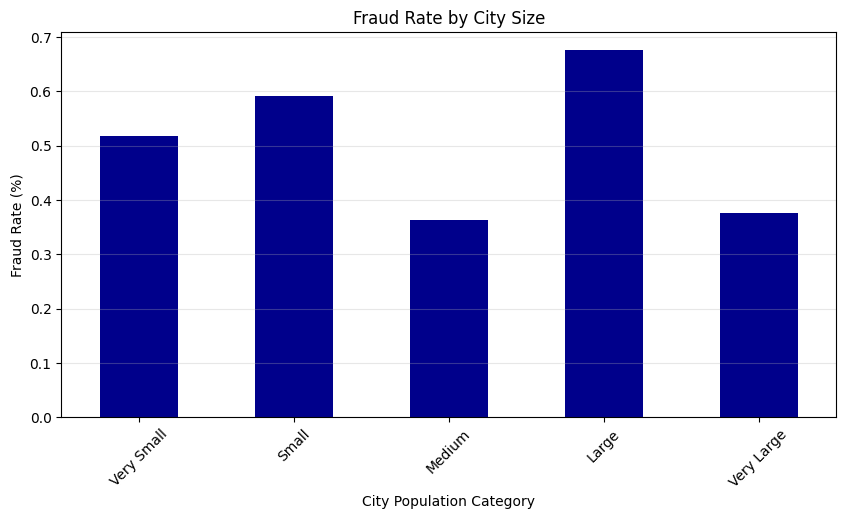

In [18]:
# Fraud rates for populations of cities
df['pop_category'] = pd.cut(df['city_pop'], 
                             bins=[0, 1000, 10000, 100000, 1000000, 10000000],
                             labels=['Very Small', 'Small', 'Medium', 'Large', 'Very Large'])

pop_fraud = df.groupby('pop_category')['is_fraud'].agg(['sum', 'count', 'mean'])
pop_fraud.columns = ['Fraud_Count', 'Total', 'Fraud_Rate']
pop_fraud['Fraud_Rate'] = pop_fraud['Fraud_Rate'] * 100

print("Fraud Rate by City Size:")
print(pop_fraud)

plt.figure(figsize=(10, 5))
pop_fraud['Fraud_Rate'].plot(kind='bar', color='darkblue')
plt.xlabel('City Population Category')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by City Size')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

Fraud Rate by Age Group:
           Fraud_Count  Total  Fraud_Rate
age_group                                
18-25              149  17622    0.845534
26-35              306  79015    0.387268
36-45              248  70064    0.353962
46-55              419  79033    0.530158
56-65              313  41469    0.754781
65+                347  52404    0.662163


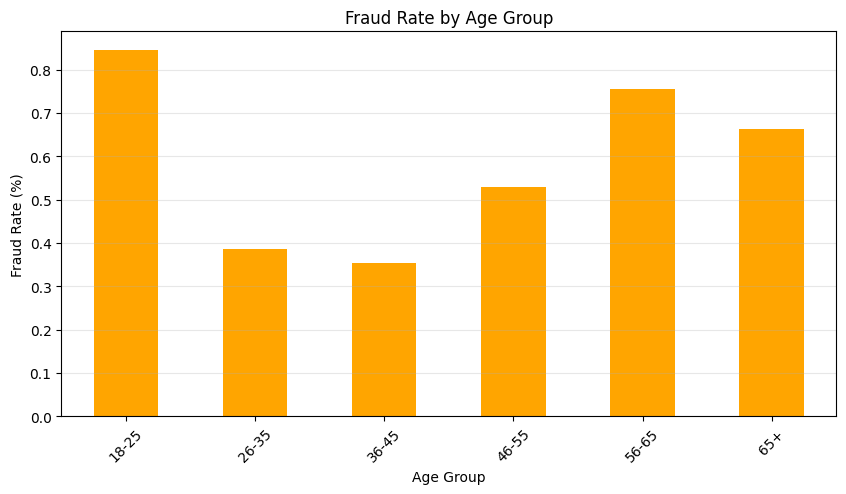

In [19]:
#Fraud Rate by the time of day it is
from datetime import datetime

df['dob_datetime'] = pd.to_datetime(df['dob'])
df['trans_year'] = df['trans_datetime'].dt.year
df['birth_year'] = df['dob_datetime'].dt.year
df['age'] = df['trans_year'] - df['birth_year']

df['age_group'] = pd.cut(df['age'], 
                         bins=[0, 25, 35, 45, 55, 65, 100],
                         labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

age_fraud = df.groupby('age_group')['is_fraud'].agg(['sum', 'count', 'mean'])
age_fraud.columns = ['Fraud_Count', 'Total', 'Fraud_Rate']
age_fraud['Fraud_Rate'] = age_fraud['Fraud_Rate'] * 100

print("Fraud Rate by Age Group:")
print(age_fraud)

plt.figure(figsize=(10, 5))
age_fraud['Fraud_Rate'].plot(kind='bar', color='orange')
plt.xlabel('Age Group')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Age Group')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

Fraud Rate by Day of Week:
           Fraud_Count  Total  Fraud_Rate
day_name                                 
Monday             328  67396    0.486676
Tuesday            225  50051    0.449541
Wednesday          198  34003    0.582302
Thursday           199  38277    0.519894
Friday             264  39818    0.663017
Saturday           296  47884    0.618161
Sunday             272  62178    0.437454


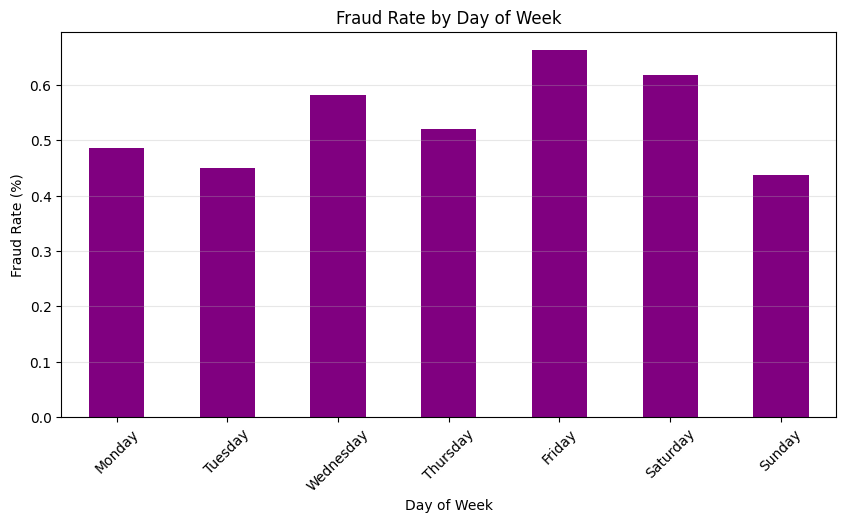

In [20]:
#Fraud rate by day of the week
df['day_of_week'] = df['trans_datetime'].dt.dayofweek
day_names = {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 
             4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
df['day_name'] = df['day_of_week'].map(day_names)

dow_fraud = df.groupby('day_name')['is_fraud'].agg(['sum', 'count', 'mean'])
dow_fraud.columns = ['Fraud_Count', 'Total', 'Fraud_Rate']
dow_fraud['Fraud_Rate'] = dow_fraud['Fraud_Rate'] * 100
dow_fraud = dow_fraud.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

print("Fraud Rate by Day of Week:")
print(dow_fraud)

plt.figure(figsize=(10, 5))
dow_fraud['Fraud_Rate'].plot(kind='bar', color='purple')
plt.xlabel('Day of Week')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Day of Week')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [21]:
print("\n" + "=" * 80)
print("DEEP DATA EXPLORATION - KEY FINDINGS")
print("=" * 80)

findings = """  
1. TRANSACTION AMOUNTS:
   - Fraud transactions are 7.6x HIGHER($518 vs $68 average)
   - Legitimate Transactions are around $0 - $600
   - Fraudulant Transactions spike around $300 - $400 and $800 - $1100
   
2. CATEGORIES:
   • Online shopping (shopping_net, misc_net) has highest fraud
   • Online fraud rate ~1.3-1.4% vs in-person ~0.3-0.6%
   
3. TIME PATTERNS:
   • Late night (10-11 PM): 2.5% fraud rate (HIGHEST)
   • Early morning (midnight-3 AM): 1.3-1.5% fraud rate
   • Daytime: Very low fraud rate
   • Weekends (Fri-Sat): Higher fraud than weekdays
   
4. GEOGRAPHY:
   • Alaska has highest fraud rate(1.69%)
   • Large cities (100k-1M pop): 0.68% fraud rate(HIGHEST)
   • Medium cities: Lowest fraud rate(0.36%)
   
5. DEMOGRAPHICS:
   • Young adults (18-25): 0.85% fraud (HIGHEST)
   • Seniors (56+): 0.66-0.75% fraud
   • Middle age (26-45): Lowest fraud (0.35%)

FEATURES TO CREATE FOR MODEL:
1. Hour of day (0-23) - fraud peaks from 10-11 pm
2. Is night transaction - binary flag 10 PM - 6 AM (2.5x more fraud)
3. Day of week - Friday has highest fraud rate
4. Is weekend - weekend vs weekday pattern
5. Amount (already have)
6. Log of amount - transform amount by logging it so amount doesn't have as big of a range (for handling transactions like $28, 948 that are outliers)
7. City population category
8. Age group
9. Category (already have)
10. State (already have)
"""

print(findings)

with open('../results/deep_exploration_findings.txt', 'w') as f:
    f.write(findings)

print("\n Findings saved to '../results/deep_exploration_findings.txt'")
print("\n" + "=" * 80)
print("=" * 80)


DEEP DATA EXPLORATION - KEY FINDINGS
  
1. TRANSACTION AMOUNTS:
   - Fraud transactions are 7.6x HIGHER($518 vs $68 average)
   - Legitimate Transactions are around $0 - $600
   - Fraudulant Transactions spike around $300 - $400 and $800 - $1100

2. CATEGORIES:
   • Online shopping (shopping_net, misc_net) has highest fraud
   • Online fraud rate ~1.3-1.4% vs in-person ~0.3-0.6%

3. TIME PATTERNS:
   • Late night (10-11 PM): 2.5% fraud rate (HIGHEST)
   • Early morning (midnight-3 AM): 1.3-1.5% fraud rate
   • Daytime: Very low fraud rate
   • Weekends (Fri-Sat): Higher fraud than weekdays

4. GEOGRAPHY:
   • Alaska has highest fraud rate(1.69%)
   • Large cities (100k-1M pop): 0.68% fraud rate(HIGHEST)
   • Medium cities: Lowest fraud rate(0.36%)

5. DEMOGRAPHICS:
   • Young adults (18-25): 0.85% fraud (HIGHEST)
   • Seniors (56+): 0.66-0.75% fraud
   • Middle age (26-45): Lowest fraud (0.35%)

FEATURES TO CREATE FOR MODEL:
1. Hour of day (0-23) - fraud peaks from 10-11 pm
2. Is nigh